## **EDA - Traffic Collision Data Ottawa**

In [ ]:
# Importation des librairies nécessaires pour l'analyse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import folium


# Configuration pour afficher toutes les colonnes lors des aperçus
pd.set_option('display.max_columns', None)

# Définition du chemin vers le fichier de données
# À adapter selon l'emplacement du fichier téléchargé
DATA_PATH = '../data/Traffic_Collision_Data.csv'

# Chargement du jeu de données dans un DataFrame pandas
df = pd.read_csv(DATA_PATH)

# Affichage des dimensions du dataset (nombre de lignes, nombre de colonnes)
print("Dimensions du dataset :", df.shape)

# Affichage des 5 premières lignes pour observer la structure des données
df.head()

Dimensions du dataset : (94406, 28)


,X,Y,X_Coordinate,Y_Coordinate,ID,Geo_ID,Accident_Year,Accident_Date,Location,Classification_Of_Accident,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,Max_injury,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
0,-8.449907e+06,5.674412e+06,351293.8071,5021841.110,2017--101,__3Z00RNB,2017,1/4/2017,MARCH RD btwn 280 S OF CARLING AVE/STATION RD ...,02 - Non-fatal injury,02 - Angle,03 - Loose snow,03 - Snow,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,Minimal,1.0,1.0,NaN,NaN,NaN,45.334978,-75.906802,1
1,-8.432341e+06,5.664915e+06,363723.6849,5015276.436,2017--201,0004726,2017,1/5/2017,GREENBANK RD @ BERRIGAN DR/WESSEX RD (0004726),03 - P.D. only,05 - Turning movement,02 - Wet,01 - Clear,07 - Dark,01 - Traffic signal,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.274975,-75.749006,2
2,-8.427552e+06,5.687484e+06,366942.7019,5031143.575,2017--801,0006357,2017,1/23/2017,ALBERT ST @ BAY ST (0006357),02 - Non-fatal injury,07 - SMV other,01 - Dry,01 - Clear,07 - Dark,01 - Traffic signal,1.0,1.0,NaN,NaN,Minimal,1.0,1.0,NaN,NaN,NaN,45.417468,-75.705989,3
3,-8.423618e+06,5.682501e+06,369744.7181,5027678.543,2017--102,0001586,2017,1/4/2017,KILBORN AVE/KILBORN PL @ LAMIRA ST (0001586),03 - P.D. only,01 - Approaching,06 - Ice,03 - Snow,05 - Dusk,11 - Roundabout,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.386036,-75.670647,4
4,-8.421028e+06,5.632923e+06,371935.0538,4992842.240,2017--103,__3Z09V2,2017,1/4/2017,DONNELLY DR btwn FAIRMILE RD & FOURTH LINE RD ...,03 - P.D. only,04 - Sideswipe,03 - Loose snow,03 - Snow,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.072377,-75.647379,5


Variables d'intérêt pour le clustering :

Classification_Of_Accident : gravité (non-fatal injury, P.D. only)

Initial_Impact_Type : type d'impact (angle, turning movement, etc.)

Road_1_Surface_Condition : état de la chaussée

Environment_Condition_1 : conditions météo

Light : luminosité

Traffic_Control : type de contrôle de circulation

num_of_vehicles, num_of_pedestrians, num_of_bicycles, num_of_motorcycles : usagers impliqués

Max_injury, num_of_injuries, num_of_minimal, num_of_minor, num_of_major, num_of_fatal : gravité des blessures

In [3]:
# Affichage des types de données de chaque colonne
print("Types de données :")
print(df.dtypes)

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

# Statistiques descriptives pour les colonnes numériques
print("\nStatistiques descriptives (numériques) :")
df.describe()

Types de données :
X                             float64
Y                             float64
X_Coordinate                  float64
Y_Coordinate                  float64
ID                                str
Geo_ID                            str
Accident_Year                   int64
Accident_Date                     str
Location                          str
Classification_Of_Accident        str
Initial_Impact_Type               str
Road_1_Surface_Condition          str
Environment_Condition_1           str
Light                             str
Traffic_Control                   str
num_of_vehicles               float64
num_of_pedestrians            float64
num_of_bicycles               float64
num_of_motorcycles            float64
Max_injury                        str
num_of_injuries               float64
num_of_minimal                float64
num_of_minor                  float64
num_of_major                  float64
num_of_fatal                  float64
Lat                           f

,X,Y,X_Coordinate,Y_Coordinate,Accident_Year,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
count,9.440600e+04,9.440600e+04,94406.000000,9.440600e+04,94406.000000,94238.000000,1831.000000,1665.00000,791.000000,15223.000000,6590.000000,8656.000000,817.000000,169.000000,94406.000000,94406.000000,94406.000000
mean,-8.427894e+06,5.675457e+06,366681.116243,5.021918e+06,2020.132439,1.866349,1.038777,1.00961,1.015171,1.293438,1.208194,1.219616,1.112607,1.065089,45.334280,-75.709057,47203.500000
std,1.753820e+04,1.571708e+05,13998.163610,1.389519e+05,2.367294,0.564350,0.204120,0.10921,0.132254,0.719960,0.554833,0.576199,0.583305,0.270406,1.254323,0.157548,27252.809094
min,-8.820655e+06,0.000000e+00,0.000000,0.000000e+00,2017.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-79.237290,1.000000
25%,-8.432998e+06,5.674030e+06,363180.599300,5.021664e+06,2018.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.332566,-75.754909,23602.250000
50%,-8.426562e+06,5.681332e+06,367649.068150,5.026852e+06,2020.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.378657,-75.697095,47203.500000
75%,-8.420494e+06,5.687625e+06,371921.717000,5.031271e+06,2022.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.418357,-75.642588,70804.750000
max,-8.378081e+06,5.704542e+06,401821.931000,5.043439e+06,2024.000000,25.000000,3.000000,3.00000,3.000000,38.000000,11.000000,10.000000,14.000000,3.000000,45.524921,-75.261583,94406.000000


Observations clés :

Valeurs manquantes massives : les colonnes num_of_pedestrians, num_of_bicycles, num_of_motorcycles et les colonnes de blessures (num_of_injuries, num_of_minimal, etc.) ont plus de 80 % de valeurs manquantes. Cela indique que ces colonnes ne sont renseignées que lorsqu'il y a des usagers vulnérables ou des blessés. Nous devrons les traiter avec précaution.

Données géographiques complètes : les coordonnées Lat et Long sont disponibles pour toutes les lignes, ce qui est excellent pour le clustering spatial.

Colonnes temporelles : Accident_Date est au format texte (ex : "1/4/2017"), à convertir en datetime.

Colonnes catégorielles : Classification_Of_Accident, Initial_Impact_Type, Road_1_Surface_Condition, etc. contiennent des valeurs avec des préfixes numériques (ex : "02 - Non-fatal injury"). Nous nettoierons cela.

Colonnes à exclure probablement : X, Y, X_Coordinate, Y_Coordinate sont des redondances des coordonnées dans différents systèmes. Nous garderons Lat et Long.

In [4]:
# Analyse des colonnes catégorielles principales
categorical_cols = [
    'Classification_Of_Accident',
    'Initial_Impact_Type', 
    'Road_1_Surface_Condition',
    'Environment_Condition_1',
    'Light',
    'Traffic_Control',
    'Max_injury'
]

print("Valeurs uniques par colonne catégorielle :")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))

# Conversion de la colonne de date
df['Accident_Date'] = pd.to_datetime(df['Accident_Date'])
df['month'] = df['Accident_Date'].dt.month
df['day_of_week'] = df['Accident_Date'].dt.dayofweek
df['hour'] = pd.to_numeric(df['Accident_Date'].dt.hour, errors='coerce')

# Création d'une colonne de gravité binaire pour analyses futures
df['is_injury'] = df['Classification_Of_Accident'].apply(
    lambda x: 1 if 'injury' in str(x).lower() else 0
)

print("\nAperçu après transformation :")
print(df[['Accident_Date', 'month', 'day_of_week', 'hour', 'is_injury']].head())

Valeurs uniques par colonne catégorielle :

Classification_Of_Accident:
Classification_Of_Accident
03 - P.D. only           76671
02 - Non-fatal injury    15002
04 - Non-reportable       2563
01 - Fatal injury          170
Name: count, dtype: int64

Initial_Impact_Type:
Initial_Impact_Type
03 - Rear end                  31720
07 - SMV other                 14197
04 - Sideswipe                 13616
02 - Angle                     11825
05 - Turning movement          11164
06 - SMV unattended vehicle     8206
99 - Other                      2387
01 - Approaching                1279
NaN                               12
Name: count, dtype: int64

Road_1_Surface_Condition:
Road_1_Surface_Condition
01 - Dry                     64171
02 - Wet                     15654
03 - Loose snow               5430
06 - Ice                      3440
04 - Slush                    3056
05 - Packed snow              2366
00 - Unknown                   101
99 - Other                      85
08 - Loose sand or

Gravité des accidents :

81 % sont des dommages matériels seulement (P.D. only)

16 % sont des blessures non mortelles

0,2 % sont des accidents mortels (170 cas)

Types d'impact dominants :

Collisions par l'arrière (33 %)

SMV other (Single Motor Vehicle, 15 %)

Sideswipe (14 %)

Angle (13 %)

Conditions routières :

68 % sur chaussée sèche

17 % sur chaussée mouillée

Le reste partagé entre neige, glace, slush

Environnement :

79 % par temps clair

10 % sous la neige

9 % sous la pluie

Luminosité :

68 % en plein jour

22 % dans l'obscurité

Contrôle de circulation :

46 % sans contrôle

41 % avec feux de signalisation

11 % avec panneaux d'arrêt

Problème identifié : La colonne Max_injury a 84 % de valeurs manquantes, mais l'information de gravité est déjà présente dans Classification_Of_Accident. Nous pouvons utiliser cette dernière.

## **Analyse Spatiale (préliminaire)**

In [5]:
# Imports
import folium
from folium.plugins import HeatMap

In [6]:
# Analyse spatiale de base
print("Étendue géographique des données :")
print(f"Latitude : min = {df['Lat'].min():.4f}, max = {df['Lat'].max():.4f}")
print(f"Longitude : min = {df['Long'].min():.4f}, max = {df['Long'].max():.4f}")

# Visualisation simple des points sur une carte

# Création d'une carte centrée sur Ottawa
map_center = [45.4215, -75.6972]
map_preview = folium.Map(location=map_center, zoom_start=11)

# Ajout des points d'accidents
sample = df.sample(n=5000, random_state=42)  # Échantillon pour performance
for _, row in sample.iterrows():
    color = 'red' if row['is_injury'] == 1 else 'blue'
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius=2,
        color=color,
        fill=True,
        popup=row['Classification_Of_Accident']
    ).add_to(map_preview)

map_preview.save('accidents_preview.html')
print("Carte sauvegardée sous 'accidents_preview.html'")

# Analyse des accidents par mois
monthly_counts = df.groupby('month').size()
monthly_injury = df.groupby('month')['is_injury'].mean()

print("\nAccidents par mois :")
print(monthly_counts)
print("\nProportion d'accidents avec blessures par mois :")
print(round(monthly_injury * 100, 1))

Étendue géographique des données :
Latitude : min = 0.0000, max = 45.5249
Longitude : min = -79.2373, max = -75.2616
Carte sauvegardée sous 'accidents_preview.html'

Accidents par mois :
month
1     9849
2     8856
3     6824
4     5545
5     6889
6     7077
7     7062
8     6961
9     7970
10    8358
11    9411
12    9604
dtype: int64

Proportion d'accidents avec blessures par mois :
month
1     12.5
2     12.9
3     13.9
4     15.5
5     18.0
6     18.4
7     19.7
8     19.8
9     19.1
10    17.1
11    15.2
12    13.5
Name: is_injury, dtype: float64


# **Visualisations**

In [7]:
# Configuration des graphiques dans le notebook
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Style des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Visualisation 1 : Distribution spatiale des accidents

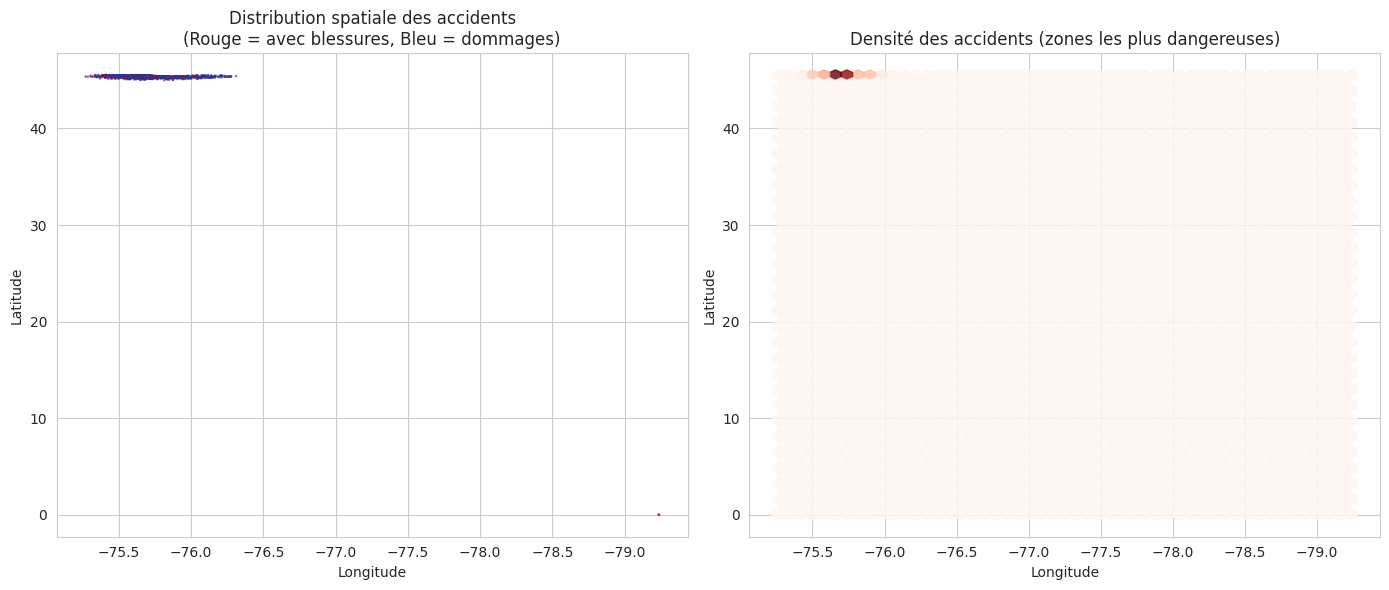

In [9]:
# Distribution spatiale des accidents
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot des accidents (échantillon pour lisibilité)
sample = df.sample(n=5000, random_state=42)

ax[0].scatter(sample['Long'], sample['Lat'], c=sample['is_injury'], 
              cmap='RdYlBu_r', s=1, alpha=0.5)
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')
ax[0].set_title('Distribution spatiale des accidents\n(Rouge = avec blessures, Bleu = dommages)')
ax[0].invert_xaxis()  # Pour orientation standard

# Heatmap 2D de densité
heatmap_data = df[['Long', 'Lat']].dropna()
ax[1].hexbin(heatmap_data['Long'], heatmap_data['Lat'], gridsize=50, cmap='Reds', alpha=0.8)
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
ax[1].set_title('Densité des accidents (zones les plus dangereuses)')
ax[1].invert_xaxis()

plt.tight_layout()
plt.show()

**Observation:** <br />
Ici on a une concentration massive d'accidents sur un axe précis (latitude ~45°), où la superposition des points rouges et bleus indique une mixité entre dommages corporels et matériels. La carte de densité à droite confirme un point noir majeur (hexagone sombre) qui concentre l'essentiel du danger statistique. Toutefois, la présence d'un point isolé à la coordonnée (0, -79) trahit une anomalie de saisie GPS (valeurs aberrantes), indiquant que les données nécessitent un nettoyage avant toute analyse décisionnelle approfondie.

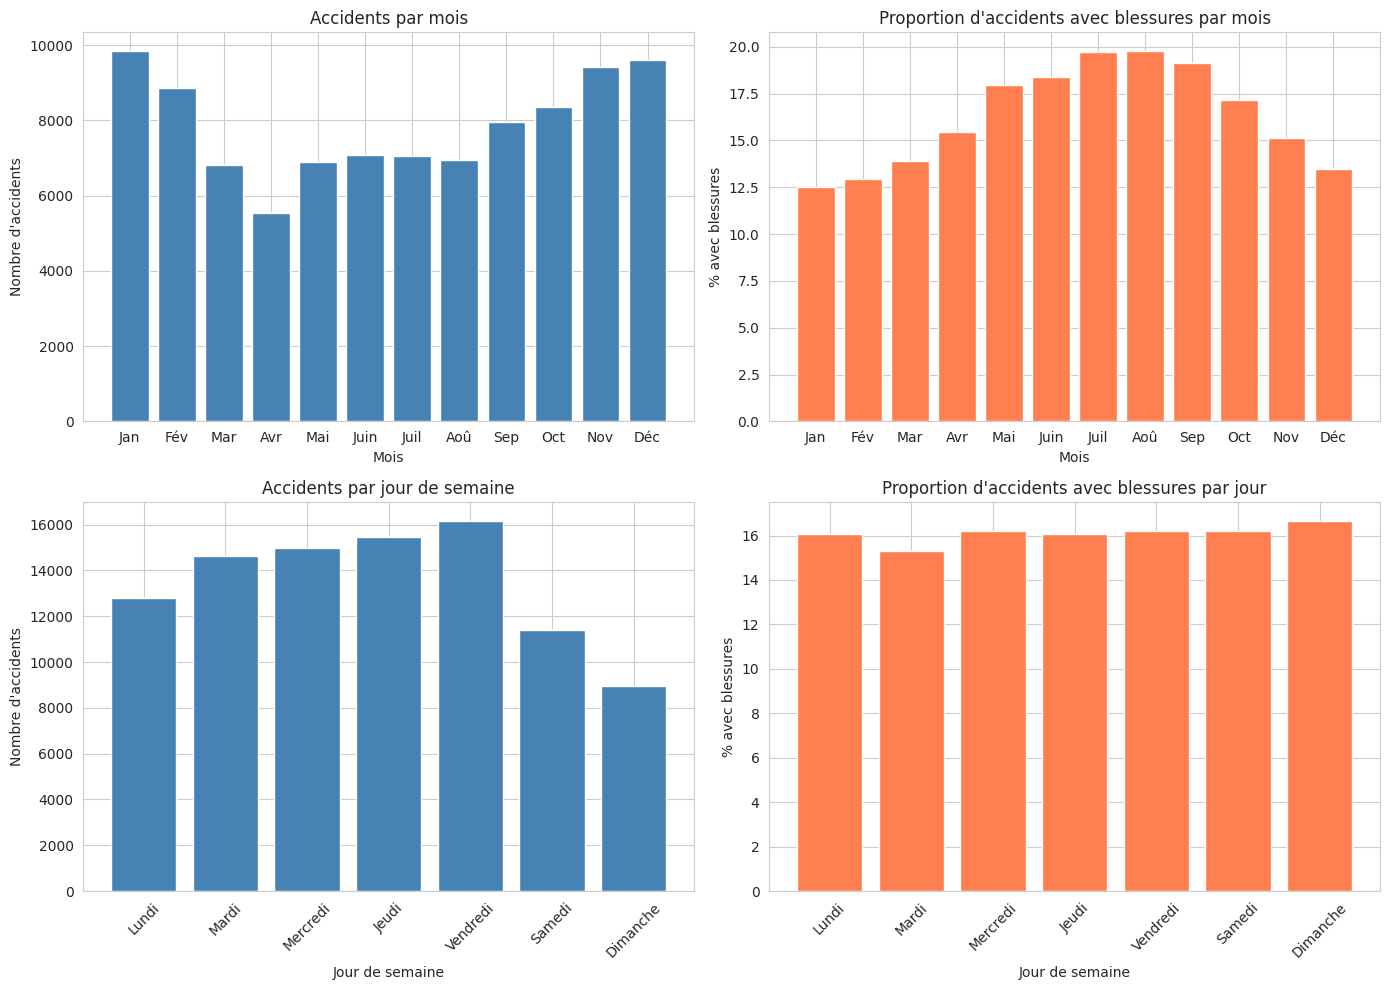

In [10]:
# Visualisation 2 : Évolution temporelle
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Par mois
monthly_counts = df.groupby('month').size()
monthly_injury = df.groupby('month')['is_injury'].mean() * 100

axes[0, 0].bar(monthly_counts.index, monthly_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Mois')
axes[0, 0].set_ylabel('Nombre d\'accidents')
axes[0, 0].set_title('Accidents par mois')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
                             'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])

# Proportion de blessures par mois
axes[0, 1].bar(monthly_injury.index, monthly_injury.values, color='coral')
axes[0, 1].set_xlabel('Mois')
axes[0, 1].set_ylabel('% avec blessures')
axes[0, 1].set_title('Proportion d\'accidents avec blessures par mois')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
                             'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])

# Par jour de semaine
weekday_counts = df.groupby('day_of_week').size()
weekday_injury = df.groupby('day_of_week')['is_injury'].mean() * 100
weekday_names = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

axes[1, 0].bar(weekday_names, weekday_counts.values, color='steelblue')
axes[1, 0].set_xlabel('Jour de semaine')
axes[1, 0].set_ylabel('Nombre d\'accidents')
axes[1, 0].set_title('Accidents par jour de semaine')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Proportion de blessures par jour
axes[1, 1].bar(weekday_names, weekday_injury.values, color='coral')
axes[1, 1].set_xlabel('Jour de semaine')
axes[1, 1].set_ylabel('% avec blessures')
axes[1, 1].set_title('Proportion d\'accidents avec blessures par jour')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


**Observation:** <br />
Le nombre d'accidents est au plus haut en janvier et au plus bas en avril. Le pourcentage d'accidents avec blessures augmente progressivement de janvier pour atteindre un pic en juillet et août. Le volume des accidents croît chaque jour de la semaine du lundi jusqu'au vendredi avant de chuter le week-end. La proportion de blessures demeure stable autour de 16% pour chaque jour de la semaine.

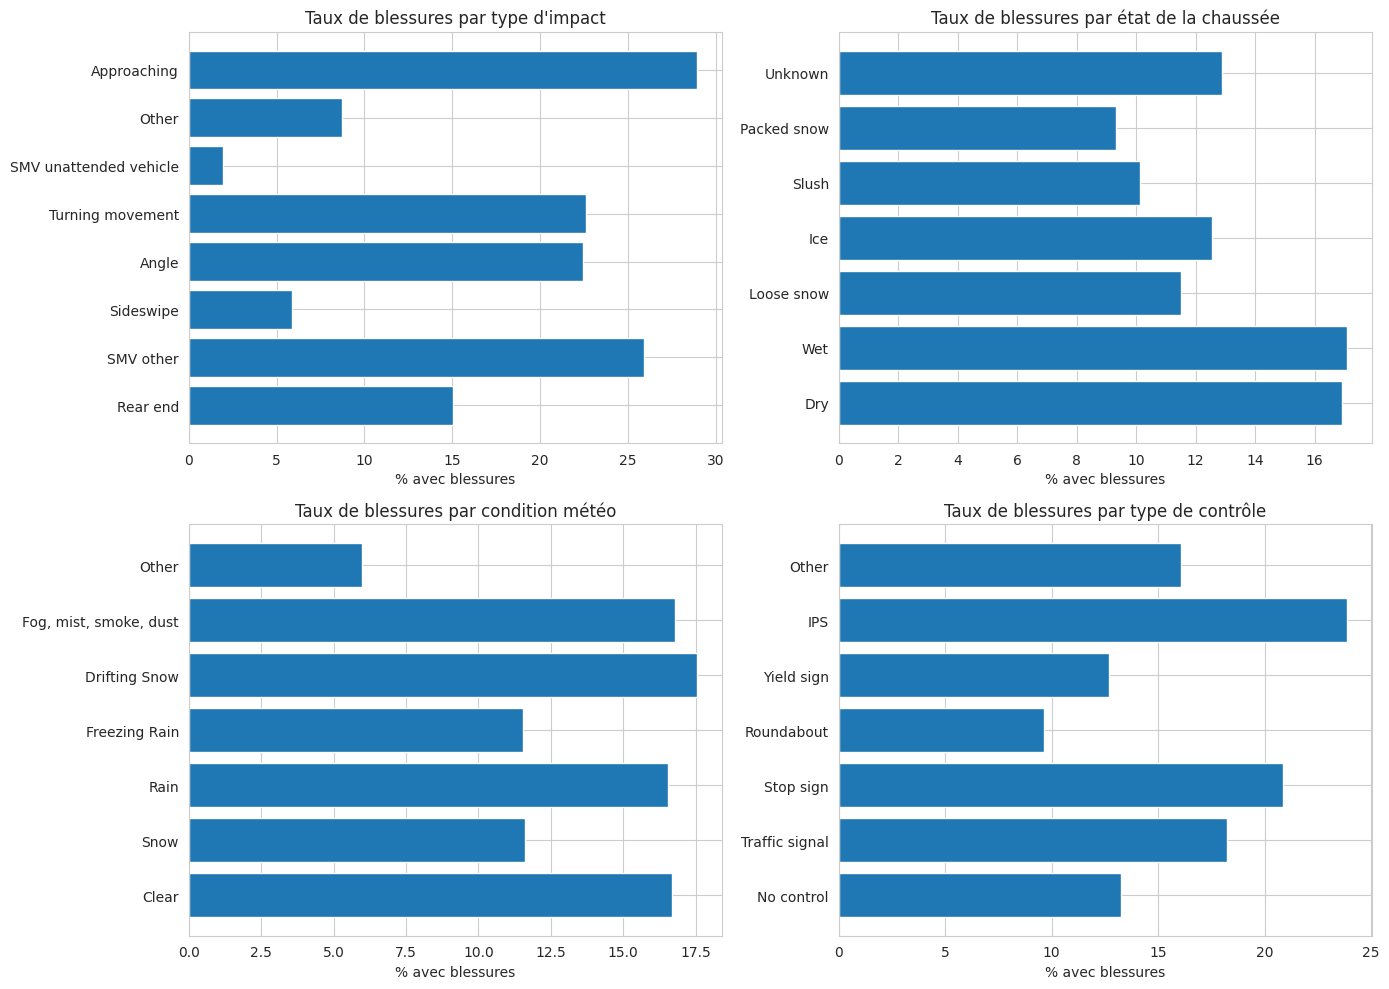

In [11]:
# Visualisation 3 : Conditions associées aux accidents graves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Par type d'impact
impact_injury = df.groupby('Initial_Impact_Type')['is_injury'].mean() * 100
impact_counts = df['Initial_Impact_Type'].value_counts()
top_impacts = impact_counts.head(8).index
impact_injury_top = impact_injury[top_impacts]

axes[0, 0].barh(range(len(top_impacts)), impact_injury_top.values)
axes[0, 0].set_yticks(range(len(top_impacts)))
axes[0, 0].set_yticklabels([i.split(' - ')[1] if ' - ' in i else i for i in top_impacts])
axes[0, 0].set_xlabel('% avec blessures')
axes[0, 0].set_title('Taux de blessures par type d\'impact')

# Par état de la chaussée
surface_injury = df.groupby('Road_1_Surface_Condition')['is_injury'].mean() * 100
surface_counts = df['Road_1_Surface_Condition'].value_counts()
top_surfaces = surface_counts.head(7).index
surface_injury_top = surface_injury[top_surfaces]

axes[0, 1].barh(range(len(top_surfaces)), surface_injury_top.values)
axes[0, 1].set_yticks(range(len(top_surfaces)))
axes[0, 1].set_yticklabels([s.split(' - ')[1] if ' - ' in s else s for s in top_surfaces])
axes[0, 1].set_xlabel('% avec blessures')
axes[0, 1].set_title('Taux de blessures par état de la chaussée')

# Par conditions météo
weather_injury = df.groupby('Environment_Condition_1')['is_injury'].mean() * 100
weather_counts = df['Environment_Condition_1'].value_counts()
top_weather = weather_counts.head(7).index
weather_injury_top = weather_injury[top_weather]

axes[1, 0].barh(range(len(top_weather)), weather_injury_top.values)
axes[1, 0].set_yticks(range(len(top_weather)))
axes[1, 0].set_yticklabels([w.split(' - ')[1] if ' - ' in w else w for w in top_weather])
axes[1, 0].set_xlabel('% avec blessures')
axes[1, 0].set_title('Taux de blessures par condition météo')

# Par type de contrôle
control_injury = df.groupby('Traffic_Control')['is_injury'].mean() * 100
control_counts = df['Traffic_Control'].value_counts()
top_controls = control_counts.head(7).index
control_injury_top = control_injury[top_controls]

axes[1, 1].barh(range(len(top_controls)), control_injury_top.values)
axes[1, 1].set_yticks(range(len(top_controls)))
axes[1, 1].set_yticklabels([c.split(' - ')[1] if ' - ' in c else c for c in top_controls])
axes[1, 1].set_xlabel('% avec blessures')
axes[1, 1].set_title('Taux de blessures par type de contrôle')

plt.tight_layout()
plt.show()

**Observation:** <br />
Les impacts de type "Approaching" enregistrent le taux de blessures le plus élevé alors que les véhicules stationnés ("SMV unattended vehicle") affichent le plus bas. Le pourcentage de blessures est maximal lorsque la chaussée est mouillée ou sèche et diminue sur les surfaces enneigées ou glacées. Les conditions de neige poudreuse ("Drifting Snow") présentent le taux de blessures le plus important par rapport aux autres conditions météorologiques. Les dispositifs de contrôle de type "IPS" et "Stop sign" sont associés aux taux de blessures les plus élevés tandis que les ronds-points affichent le taux le plus faible.

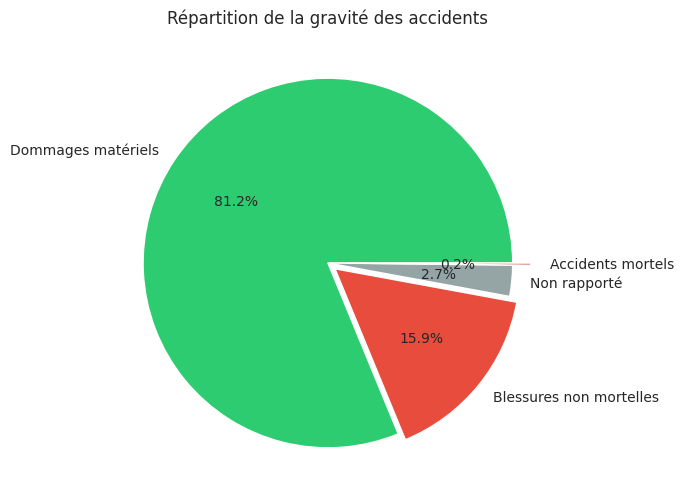

In [12]:
# Visualisation 4 : Répartition de la gravité
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
severity_counts = df['Classification_Of_Accident'].value_counts()
severity_labels = ['Dommages matériels', 'Blessures non mortelles', 'Non rapporté', 'Accidents mortels']
severity_values = [severity_counts.get('03 - P.D. only', 0),
                   severity_counts.get('02 - Non-fatal injury', 0),
                   severity_counts.get('04 - Non-reportable', 0),
                   severity_counts.get('01 - Fatal injury', 0)]

wedges, texts, autotexts = ax.pie(severity_values, labels=severity_labels, autopct='%1.1f%%',
                                   colors=['#2ecc71', '#e74c3c', '#95a5a6', '#c0392b'],
                                   explode=(0, 0.05, 0, 0.1))
ax.set_title('Répartition de la gravité des accidents')
plt.show()

**Observation:** <br />
Les dommages matériels constituent la grande majorité des accidents avec une part de 81,2 %. Les blessures non mortelles représentent 15,9 % du total des événements. Les cas non rapportés comptent pour 2,7 % de la répartition. Les accidents mortels forment la catégorie la plus réduite avec un taux de 0,2 %.

## **Synthèse des Insights**
Synthèse des insights clés
1. Anomalies spatiales à corriger
Un point aberrant à (0, -79) doit être supprimé

La zone la plus dense se situe autour de la latitude 45.4°, longitude -75.7° (centre-ville d'Ottawa)

La carte de densité confirme un "point noir" majeur à investiguer

2. Tendances temporelles
Hiver : volume maximal (janvier) mais taux de blessures faible (conditions glissantes → vitesse réduite ?)

Été : volume modéré mais taux de blessures maximal (vitesses plus élevées, plus de piétons/cyclistes ?)

Jour de semaine : volume maximal le vendredi, taux de blessures stable (~16 %)

3. Facteurs de risque
Taux de blessures élevé : impacts "Approaching" (approche), chaussée mouillée/sèche, neige poudreuse, contrôle IPS/Stop sign

Taux de blessures faible : véhicules stationnés, ronds-points, surfaces glacées/enneigées

4. Gravité
81 % dommages matériels, 16 % blessures non mortelles, 0,2 % mortels

